PREMIUM_TXN_ID
POLICY_ID
CUSTOMER_ID
DUE_DATE
PAID_DATE
PREMIUM_AMOUNT
PAYMENT_STATUS
PAYMENT_METHOD
PAYMENT_DELAY_DAYS
CHANNEL_COST

GRAIN ->1 row = 1 premium/payment transaction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

In [3]:
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data" / "raw"

premiums_df = pd.read_csv(
    DATA_DIR / "premiums.csv"
)

policies_df = pd.read_csv(
    DATA_DIR / "policies.csv"
)

print("Premiums:", premiums_df.shape)
print("Policies :", policies_df.shape)

premiums_df.head()

Premiums: (100000, 10)
Policies : (150000, 15)


,PREMIUM_TXN_ID,POLICY_ID,CUSTOMER_ID,DUE_DATE,PAID_DATE,PREMIUM_AMOUNT,PAYMENT_STATUS,PAYMENT_METHOD,PAYMENT_DELAY_DAYS,CHANNEL_COST
0,PRM000000001,POL000067000,CUST00091358,2026-07-09,2026-07-11,3469,Paid,Net Banking,2.0,122.68
1,PRM000000002,POL000077006,CUST00080746,2026-07-13,NaN,16283,Overdue,Auto Debit,NaN,473.45
2,PRM000000003,POL000045385,CUST00051940,2025-05-01,2025-05-02,2224,Paid,Cheque,1.0,67.58
3,PRM000000004,POL000060166,CUST00098054,2026-01-05,2026-01-05,3840,Paid,UPI,0.0,105.30
4,PRM000000005,POL000072081,CUST00072564,2026-04-16,2026-04-29,22707,Paid,UPI,13.0,782.68


DUE_DATE     → object
PAID_DATE    → object

In [4]:
premiums_df["DUE_DATE"] = pd.to_datetime(
    premiums_df["DUE_DATE"],
    errors="coerce"
)

premiums_df["PAID_DATE"] = pd.to_datetime(
    premiums_df["PAID_DATE"],
    errors="coerce"
)

First payment KPI — Payment Status

In [5]:
payment_status = (
    premiums_df["PAYMENT_STATUS"]
    .value_counts()
)

payment_status

PAYMENT_STATUS
Paid       91161
Overdue     3979
Pending     2846
Failed      2014
Name: count, dtype: int64

In [6]:
payment_status_pct = (
    premiums_df["PAYMENT_STATUS"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

payment_status_pct

PAYMENT_STATUS
Paid       91.16
Overdue     3.98
Pending     2.85
Failed      2.01
Name: proportion, dtype: float64

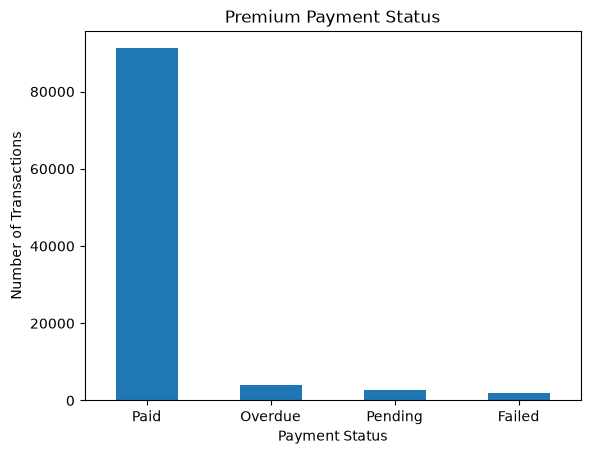

In [7]:
payment_status.plot(
    kind="bar"
)

plt.title("Premium Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

Transaction-level premium amount

In [8]:
total_premium_amount = (
    premiums_df["PREMIUM_AMOUNT"].sum()
)

avg_premium_transaction = (
    premiums_df["PREMIUM_AMOUNT"].mean()
)

print(
    "Total Premium Transaction Amount:",
    total_premium_amount
)

print(
    "Average Premium Transaction:",
    round(avg_premium_transaction, 2)
)

Total Premium Transaction Amount: 1066934005
Average Premium Transaction: 10669.34


In [9]:
paid_df = premiums_df[
    premiums_df["PAYMENT_STATUS"] == "Paid"
].copy()

In [10]:
paid_premium_amount = (
    paid_df["PREMIUM_AMOUNT"].sum()
)

print(
    "Paid Premium Amount:",
    paid_premium_amount
)

Paid Premium Amount: 971986568


Collection Rate — two versions

Transaction count

Paid transactions
----------------- × 100
All transactions

Premium value

Paid premium amount
------------------- × 100
Total premium amount

Let's calculate both.

In [11]:
transaction_success_rate = (
    len(paid_df)
    /
    len(premiums_df)
    * 100
)

value_collection_rate = (
    paid_premium_amount
    /
    total_premium_amount
    * 100
)

print(
    "Transaction Success Rate:",
    round(transaction_success_rate, 2),
    "%"
)

print(
    "Premium Value Collection Rate:",
    round(value_collection_rate, 2),
    "%"
)

Transaction Success Rate: 91.16 %
Premium Value Collection Rate: 91.1 %


In [12]:
# Payment Delay Analysis
paid_df["PAYMENT_DELAY_DAYS"].describe()

count    91161.000000
mean         6.744704
std          8.159359
min          0.000000
25%          0.000000
50%          4.000000
75%         12.000000
max         60.000000
Name: PAYMENT_DELAY_DAYS, dtype: float64

In [13]:
# On-time vs late payment
on_time_count = (
    paid_df["PAYMENT_DELAY_DAYS"] <= 0
).sum()

late_count = (
    paid_df["PAYMENT_DELAY_DAYS"] > 0
).sum()

print("On-time payments:", on_time_count)
print("Late payments:", late_count)

On-time payments: 36388
Late payments: 54773


In [14]:
print(
    "On-time %",
    round(
        on_time_count / len(paid_df) * 100,
        2
    )
)

print(
    "Late %",
    round(
        late_count / len(paid_df) * 100,
        2
    )
)

On-time % 39.92
Late % 60.08


In [15]:
# Create Payment Delay Buckets
paid_df["DELAY_BUCKET"] = pd.cut(
    paid_df["PAYMENT_DELAY_DAYS"],
    bins=[
        -1,
        0,
        7,
        15,
        30,
        float("inf")
    ],
    labels=[
        "On Time",
        "1-7 Days",
        "8-15 Days",
        "16-30 Days",
        "30+ Days"
    ]
)

In [16]:
paid_df[
    "DELAY_BUCKET"
].value_counts().sort_index()

DELAY_BUCKET
On Time       36388
1-7 Days      20958
8-15 Days     19463
16-30 Days    13243
30+ Days       1109
Name: count, dtype: int64

In [17]:
# Payment Method Analysis
payment_method_summary = (
    premiums_df
    .groupby("PAYMENT_METHOD")
    .agg(
        TRANSACTIONS=(
            "PREMIUM_TXN_ID",
            "count"
        ),

        TOTAL_PREMIUM=(
            "PREMIUM_AMOUNT",
            "sum"
        ),

        PAID_TRANSACTIONS=(
            "PAYMENT_STATUS",
            lambda x: (x == "Paid").sum()
        ),

        FAILED_TRANSACTIONS=(
            "PAYMENT_STATUS",
            lambda x: (x == "Failed").sum()
        ),

        OVERDUE_TRANSACTIONS=(
            "PAYMENT_STATUS",
            lambda x: (x == "Overdue").sum()
        ),

        AVG_PAYMENT_DELAY=(
            "PAYMENT_DELAY_DAYS",
            "mean"
        ),

        TOTAL_CHANNEL_COST=(
            "CHANNEL_COST",
            "sum"
        )
    )
    .reset_index()
)

In [18]:
payment_method_summary[
    "SUCCESS_RATE_PCT"
] = (
    payment_method_summary[
        "PAID_TRANSACTIONS"
    ]
    /
    payment_method_summary[
        "TRANSACTIONS"
    ]
    * 100
)

In [19]:
payment_method_summary.sort_values(
    "SUCCESS_RATE_PCT",
    ascending=False
)

,PAYMENT_METHOD,TRANSACTIONS,TOTAL_PREMIUM,PAID_TRANSACTIONS,FAILED_TRANSACTIONS,OVERDUE_TRANSACTIONS,AVG_PAYMENT_DELAY,TOTAL_CHANNEL_COST,SUCCESS_RATE_PCT
2,Credit Card,16594,178324497,15226,302,599,6.775384,5339019.33,91.756056
3,Debit Card,16558,172489848,15109,325,667,6.691773,5187957.02,91.248943
4,Net Banking,16577,178219502,15122,332,659,6.913636,5361966.95,91.222779
1,Cheque,16956,180934427,15436,357,699,6.725706,5412121.76,91.035622
0,Auto Debit,16595,177073129,15085,350,676,6.642890,5350586.99,90.900874
5,UPI,16720,179892602,15183,348,679,6.718830,5395623.93,90.807416


Channel Cost

In [20]:
total_channel_cost = (
    premiums_df["CHANNEL_COST"].sum()
)

avg_channel_cost = (
    premiums_df["CHANNEL_COST"].mean()
)

print(
    "Total Channel Cost:",
    round(total_channel_cost, 2)
)

print(
    "Average Channel Cost:",
    round(avg_channel_cost, 2)
)

Total Channel Cost: 32047275.98
Average Channel Cost: 320.47


In [21]:
# Channel Cost Ratio
channel_cost_ratio = (
    total_channel_cost
    /
    total_premium_amount
    * 100
)

print(
    round(channel_cost_ratio, 2),
    "%"
)

3.0 %


In [22]:
# Monthly Premium Trend
premiums_df["DUE_MONTH"] = (
    premiums_df[
        "DUE_DATE"
    ]
    .dt.to_period("M")
)

In [23]:
monthly_premium = (
    premiums_df
    .groupby("DUE_MONTH")
    .agg(
        TRANSACTIONS=(
            "PREMIUM_TXN_ID",
            "count"
        ),

        PREMIUM_AMOUNT=(
            "PREMIUM_AMOUNT",
            "sum"
        ),

        PAID_TRANSACTIONS=(
            "PAYMENT_STATUS",
            lambda x: (x == "Paid").sum()
        )
    )
    .reset_index()
)

In [24]:
monthly_premium[
    "SUCCESS_RATE_PCT"
] = (
    monthly_premium[
        "PAID_TRANSACTIONS"
    ]
    /
    monthly_premium[
        "TRANSACTIONS"
    ]
    * 100
)

In [25]:
monthly_premium[
    "DUE_MONTH"
] = monthly_premium[
    "DUE_MONTH"
].astype(str)

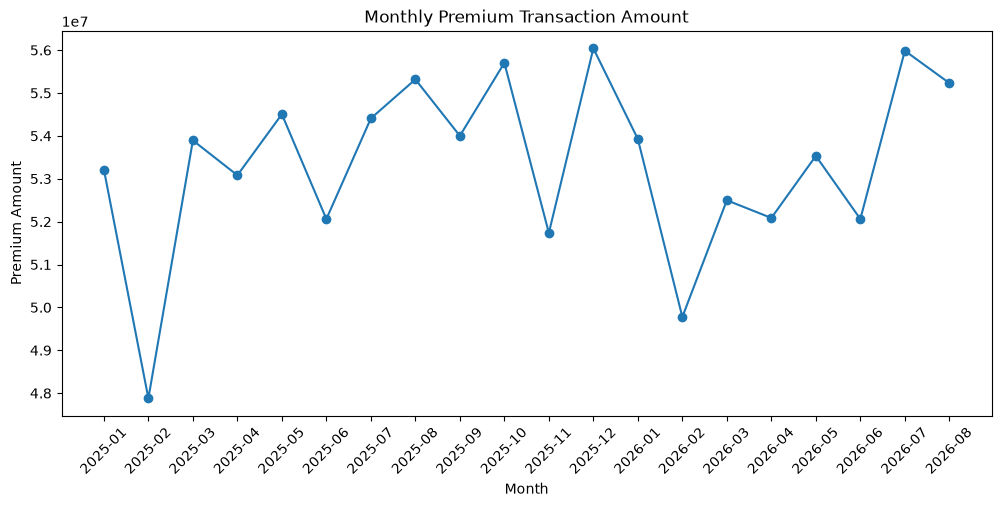

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_premium["DUE_MONTH"],
    monthly_premium["PREMIUM_AMOUNT"],
    marker="o"
)

plt.title(
    "Monthly Premium Transaction Amount"
)

plt.xlabel("Month")
plt.ylabel("Premium Amount")

plt.xticks(
    rotation=45
)

plt.show()

Merge Premiums with Policies

In [27]:
premium_policy_df = premiums_df.merge(
    policies_df[
        [
            "POLICY_ID",
            "POLICY_TYPE",
            "PAYMENT_MODE",
            "POLICY_STATUS",
            "SALES_CHANNEL"
        ]
    ],
    on="POLICY_ID",
    how="left",
    validate="many_to_one"
)

In [28]:
product_payment_summary = (
    premium_policy_df
    .groupby("POLICY_TYPE")
    .agg(
        TRANSACTIONS=(
            "PREMIUM_TXN_ID",
            "count"
        ),

        TOTAL_PREMIUM_AMOUNT=(
            "PREMIUM_AMOUNT",
            "sum"
        ),

        PAID_TRANSACTIONS=(
            "PAYMENT_STATUS",
            lambda x: (x == "Paid").sum()
        ),

        AVG_PAYMENT_DELAY=(
            "PAYMENT_DELAY_DAYS",
            "mean"
        )
    )
    .reset_index()
)

In [29]:
product_payment_summary[
    "PAYMENT_SUCCESS_RATE"
] = (
    product_payment_summary[
        "PAID_TRANSACTIONS"
    ]
    /
    product_payment_summary[
        "TRANSACTIONS"
    ]
    * 100
)

In [30]:
product_payment_summary.sort_values(
    "TOTAL_PREMIUM_AMOUNT",
    ascending=False
)

,POLICY_TYPE,TRANSACTIONS,TOTAL_PREMIUM_AMOUNT,PAID_TRANSACTIONS,AVG_PAYMENT_DELAY,PAYMENT_SUCCESS_RATE
0,Commercial,9823,261646342,8946,6.680639,91.071974
1,Health,24229,257917118,22059,6.688336,91.043790
3,Motor,21261,175799853,19355,6.861018,91.035229
5,Term Life,15738,147286921,14359,6.741834,91.237768
7,Whole Life,7005,134612662,6394,6.802784,91.277659
2,Home,8023,52161116,7336,6.742094,91.437118
4,Personal Accident,7973,25415828,7295,6.758739,91.496300
6,Travel,5948,12094165,5417,6.588148,91.072629


In [31]:
policy_payment_features = (
    premiums_df
    .groupby(
        [
            "POLICY_ID",
            "CUSTOMER_ID"
        ]
    )
    .agg(
        TOTAL_PAYMENT_TRANSACTIONS=(
            "PREMIUM_TXN_ID",
            "count"
        ),

        TOTAL_PREMIUM_AMOUNT=(
            "PREMIUM_AMOUNT",
            "sum"
        ),

        PAID_PAYMENT_COUNT=(
            "PAYMENT_STATUS",
            lambda x: (x == "Paid").sum()
        ),

        FAILED_PAYMENT_COUNT=(
            "PAYMENT_STATUS",
            lambda x: (x == "Failed").sum()
        ),

        OVERDUE_PAYMENT_COUNT=(
            "PAYMENT_STATUS",
            lambda x: (x == "Overdue").sum()
        ),

        PENDING_PAYMENT_COUNT=(
            "PAYMENT_STATUS",
            lambda x: (x == "Pending").sum()
        ),

        AVG_PAYMENT_DELAY=(
            "PAYMENT_DELAY_DAYS",
            "mean"
        ),

        MAX_PAYMENT_DELAY=(
            "PAYMENT_DELAY_DAYS",
            "max"
        ),

        TOTAL_CHANNEL_COST=(
            "CHANNEL_COST",
            "sum"
        )
    )
    .reset_index()
)

In [32]:
policy_payment_features[
    "PAYMENT_SUCCESS_RATE"
] = (
    policy_payment_features[
        "PAID_PAYMENT_COUNT"
    ]
    /
    policy_payment_features[
        "TOTAL_PAYMENT_TRANSACTIONS"
    ]
)

In [33]:
policy_payment_features.head()

,POLICY_ID,CUSTOMER_ID,TOTAL_PAYMENT_TRANSACTIONS,TOTAL_PREMIUM_AMOUNT,PAID_PAYMENT_COUNT,FAILED_PAYMENT_COUNT,OVERDUE_PAYMENT_COUNT,PENDING_PAYMENT_COUNT,AVG_PAYMENT_DELAY,MAX_PAYMENT_DELAY,TOTAL_CHANNEL_COST,PAYMENT_SUCCESS_RATE
0,POL000000001,CUST00047547,1,940,1,0,0,0,20.0,20.0,27.98,1.0
1,POL000000003,CUST00074570,2,34410,2,0,0,0,2.5,5.0,908.78,1.0
2,POL000000006,CUST00095870,1,15516,1,0,0,0,16.0,16.0,706.88,1.0
3,POL000000007,CUST00036618,1,2787,1,0,0,0,12.0,12.0,129.48,1.0
4,POL000000009,CUST00095427,1,13486,1,0,0,0,0.0,0.0,212.23,1.0


In [34]:
policy_payment_features.shape

(73102, 12)

In [35]:
policy_payment_features[
    "POLICY_ID"
].duplicated().sum()

np.int64(0)

In [36]:
PROCESSED_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [37]:
policy_payment_features.to_csv(
    PROCESSED_DIR
    / "policy_payment_features.csv",
    index=False
)

What we learned from Premium Analytics

100,000 premium transactions
          ↓
91.16% successfully Paid
          ↓
~91.10% of premium value represented
by Paid transactions
          ↓
But ~60% of successful payments
occur after due date
          ↓
Average payment delay ≈ 6.7 days
          ↓
Payment methods perform similarly
          ↓
Commercial + Health contribute
large premium transaction values
          ↓
73,102 policies have payment history
          ↓
Policy-level payment features created